# Rebuilding the joint decomposition, by hand

This notebook walks you through reimplementing the v3 joint decomposition **from scratch**,
using only `numpy`/`scipy` and the primitives of the `tracking` package. Every section
explains one piece — the model term it implements, the exact operations, and which existing
primitive to compare your implementation against. The code cells are **empty on purpose**:
you write them.

Companions, in order of usefulness:

* the **"Joint Noise Model" explainer artifact** — full derivations from probability
  densities to the algorithm box (§8–§14 are the sections this notebook implements);
* `src/tracking/AGENTS.md` — the package map: four layers, the Stage contract, and the
  primitive catalog (§1 is the stage/combinator/recipe table);
* `docs/vk-decompose-v3-design.md` and `docs/experiments/vk-decomposition.md` — the design
  record and the campaign log with every measured number quoted below.

**Ground rules learned the hard way** (each cost this project a wrong conclusion):
verify comb removal with the *full order-cell profile at all offsets* and the
*absolute excess* — never narrow slots, never peak-over-median depth (blind to broadened
lines); render the spectrogram and **look at it** before believing any instrument; and
quote phase-noise statistics in *increment* units (Hz rms), never cumulative rad rms.


## 1 · The noise model, in increments

Everything is discrete. Audio sample $n$ at rate $f_s$ (spacing $\Delta = 1/f_s$); an
envelope grid $j$ with stride $L$ samples ($f_s = 32\,$kHz, $L = 320$, $f_e = 100\,$Hz in
production). $\mathrm{lin}(\cdot)$ = linear interpolation from the envelope grid to audio.

**The carrier is a cumulative sum of the label rates** $\hat f_r[n]$ (rev/s):

$$\hat\varphi_r[n] = 2\pi\Delta \sum_{u\le n} \hat f_r[u]$$

**The noise terms are stationary rate processes; the phases are their integrals.** Two
measured facts constrain them: harmonic lines *stay on the comb* (instantaneous frequencies
never wander far from $k\hat f_r(t)$ — rate errors are **bounded**), yet harmonic *phases*
decohere completely within ~a second at high $k$ (**unbounded**). One structure delivers
both: each rate error is mean-reverting (Ornstein–Uhlenbeck; the project's synthetic-RPS
generator is exactly this, DREGON-calibrated),

$$\delta\!f_r[j] = (1-\beta)\,\delta\!f_r[j{-}1] + w_r[j], \quad w_r \sim \mathcal N(0, q_\theta/f_e),
\quad \beta = \tfrac{1}{\tau_c f_e} \ll 1$$

(same for $\delta\nu_{r,k}$ with its own $q_\varepsilon(k)$). The phase corrections are the
cumulative sums $\theta_r = \frac{2\pi}{f_e}\sum \delta\!f_r$, $\psi_{r,k} =
\frac{2\pi}{f_e}\sum \delta\nu_{r,k}$ — and a bounded frequency error still makes phase
drift arbitrarily far: the integral of a stationary process diffuses linearly for
$t \gg \tau_c$. Anchored lines, unbounded decoherence, no contradiction.

**What the solver uses** is the window-local $\tau_c \to \infty$ limit: inside a 12 s window
it penalizes only $\lVert D_2 x\rVert^2$ (second differences of the cumulative phases),
dropping the mean reversion — safe because over 12 s the two priors give nearly identical
posteriors, and the *data* pins each line's frequency to the comb wherever it has signal.
Phase position stays genuinely free (that is the physics: no permanently coherent core);
frequency position is held by the data, not by the window prior.

**Observation**, with complex envelopes $A_{r,k,c}[j]$ (magnitude = loudness, free static
angle = initial phase per mic) and a smooth-log-PSD floor $n_c$:

$$y_c[n] = \sum_{r,k} \mathrm{Re}\Big[\mathrm{lin}(A_{r,k,c})[n]\,
e^{\,i\,k(\hat\varphi_r[n] + \mathrm{lin}(\theta_r)[n]) + i\,\mathrm{lin}(\psi_{r,k})[n]}\Big] + n_c[n]$$

The MAP objective (explainer §10) is the whitened misfit $+\log S$ rent, plus one
increment penalty per process, plus amplitude and floor smoothness. The algorithm you will
build is block-coordinate descent on it: `floor → (solve → split → floor)×(I−1) → solve`.

The strengths are parameterized by −3 dB bandwidth through one shared calibration:
$\lambda(\mathrm{bw}) = (2\sin(\pi\,\mathrm{bw}/f_e))^{-4}$. Shipped values:
$\mathrm{bw}_\theta = 1.5$ Hz, $\mathrm{bw}_\psi(k) = \mathrm{clip}(0.6k,\,1.5,\,8)$ Hz,
amplitude bands 1.9–2.9 Hz from the v2 schedule.


## 2 · Orientation: the package in four layers

`src/tracking` is arranged so you only ever need two files to navigate:

| Layer | Module | Role |
|---|---|---|
| front door | `top.py` | **every** Stage + every shipped variant as a named composition |
| ladders | `pipelines.py` | calibrated multi-step algorithms |
| cores | 13 modules | one algorithm each, arrays in / arrays out |
| primitives | `dsp.py` | the shared transforms |

The Stage contract: `Stage: td.Frame -> td.Frame`, composed with `pipeline(a, b, ...)`;
combinators `iterate(stage, n)` and `windowed(inner, window_s=, hop_s=)`; diagnostics
accumulate in `meta["tracking"]`. The v3 blocks are `vk_solve_stage` / `phase_split_stage` /
`floor_stage` seeded by `joint_init_stage`, and the reference recipe is
`tracking.joint_solve_window`. You will rebuild each block as plain array code first, check
it against the core functions, and only then (optionally) wrap yours as Stages.

**Setup cell.** Import `numpy`, `scipy`, `tracking`, `tdseries as td`. Load one recording
with its refined labels — the DREGON hover `free-flight_nosource_room1` is the reference:
`scripts/vk_decompose.py` exposes `get_recording` (pass `sr=32000` **explicitly** — it is a
def-time default and module globals do nothing), or use `plots.explore.pick`. Slice a 12 s
window, keep 2 mics to stay light. Everything below runs comfortably on a laptop at this
size; full recordings go to the cluster.


In [1]:
import numpy as np
import scipy as sp
import tdseries as td
import matplotlib.pyplot as plt

import dload
from plots import dwym, explore

In [2]:
explore.datasets(sizes=True)

,name,version,samples,size
0,AVQ,50dd53d1a6c0,12,4.0 GiB
1,AVQ-egonoise,b43b374b007a,5,43.0 MiB
2,AVQ-egonoise-vkrps,266f5241bfb0,7,38.1 MiB
3,AVQ-raw,0e17e52b16c3,26,534.0 MiB
4,AeroSonicDB,0d5543419ea5,1895,4.1 GiB
5,DN-LM-train,4576c1679b3b,6481,596.2 MiB
6,DN-LM-valid,f6e7038600b9,721,66.2 MiB
7,DREGON,db39bcf762d0,357,2.8 GiB
8,DREGON-LM-V2-train,8a81bf7b7b5d,6001,1.9 GiB
9,DREGON-LM-V2-valid,1eb8384871be,601,193.0 MiB


In [3]:
rec = explore.pick('DREGON-frames', 'free-flight_nosource_room1')
rec = rec.shift(-rec.t_start)
print(rec.t_start)

0.0


/home/flyingleafe/Research/PhD/projects/harmonic-noise-suppression/src/plots/explore.py:131: UserWarning: coerce_frame: using entry 'motors_measured' as 'rps' — pass rps='motors_measured' to make the mapping explicit
  return coerce_frame(frame, **present)


In [4]:
slice = rec.time[12:30]

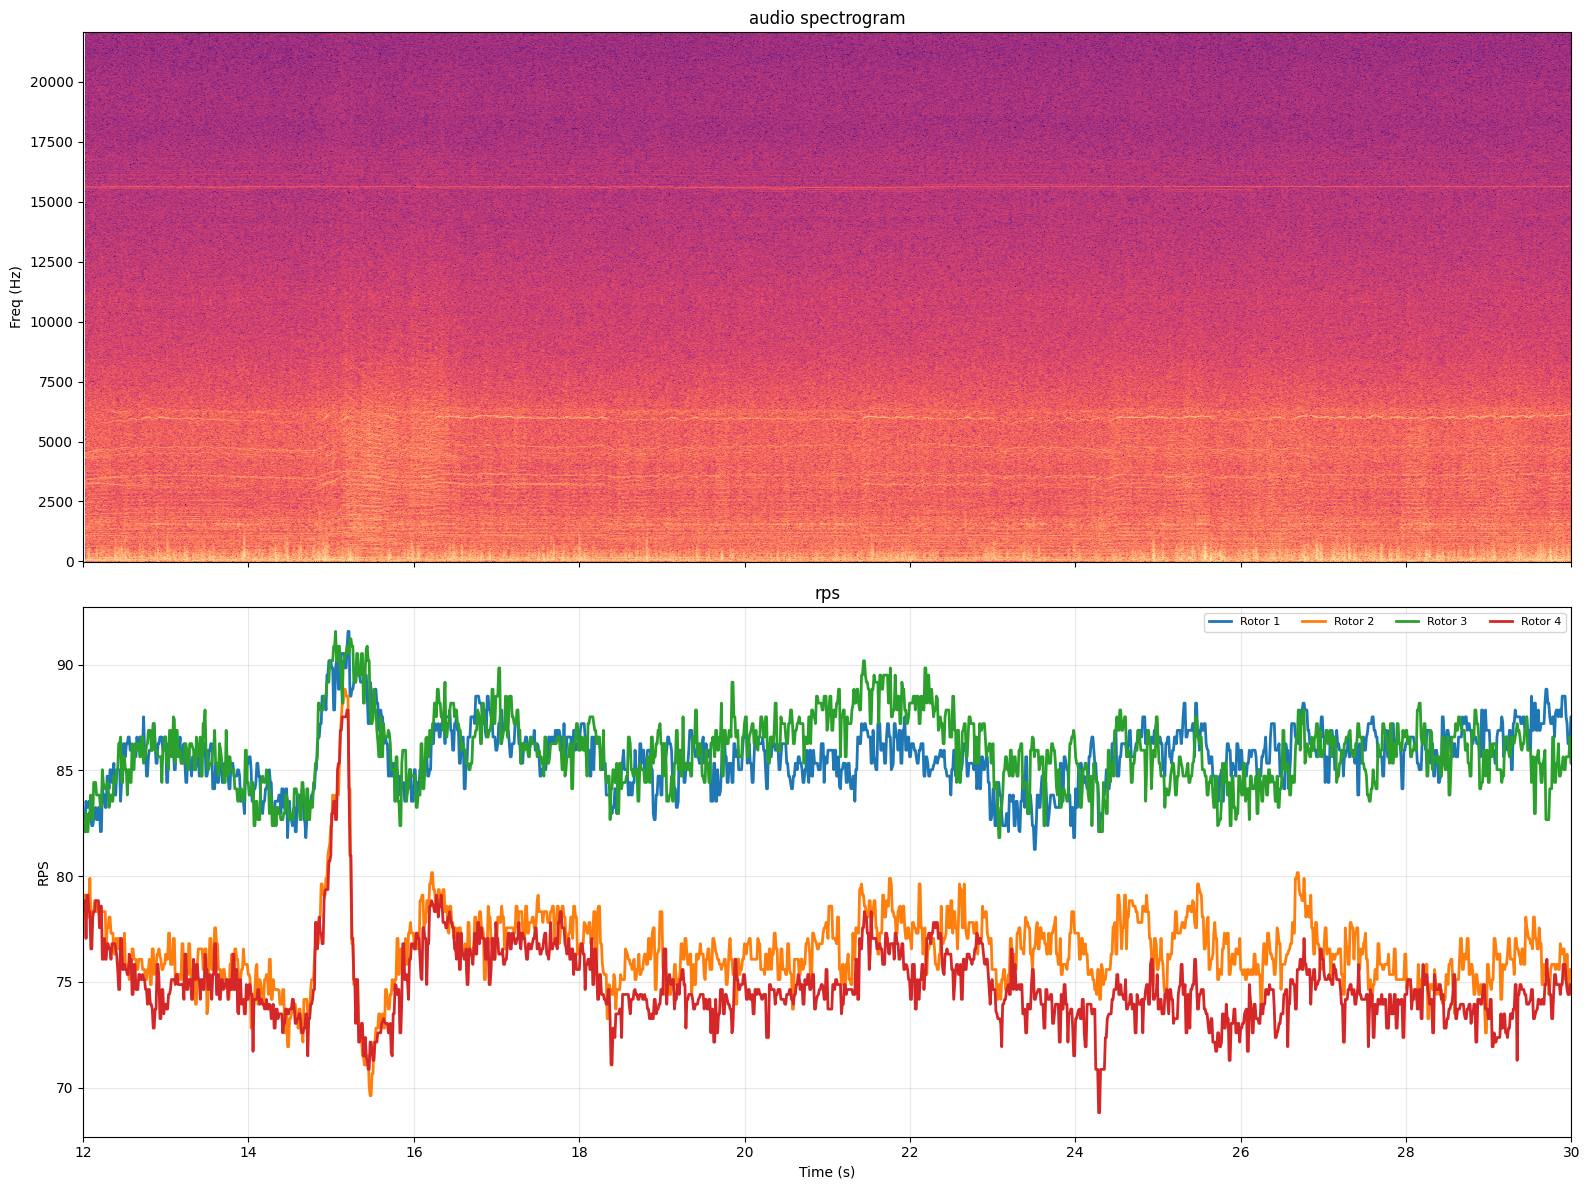

audio


In [5]:
dwym(slice)

## 3 · The carrier

Build $\hat\varphi_r[n] = 2\pi\Delta\,\mathrm{cumsum}(\hat f_r)$ for each rotor from the
label rates, and the per-track phases $\Phi_m = k_m \hat\varphi_{r_m}$ for tracks
$m = (r, k)$, $k = 1 \dots k_{\mathrm{hi}}$ (cap lines at $0.375 f_s$).

*Check:* `tracking.joint_init_stage` (or `joint_state`) builds exactly this carrier; the
project's rule that the carrier is *held* in the solver state, never re-derived, exists
because re-interpolating it perturbs phases at the $10^{-7}$ rad level and breaks
bit-reproducibility.


In [6]:
audio_sr = rec['audio'].indexes['time'].sr
rps_resampled = rec['rps'].resample(audio_sr)

In [7]:
phi_hat = rps_resampled.map_data(lambda arr: 2*np.pi*np.cumsum(arr/audio_sr, axis=-1))

In [8]:
Phi = np.arange(1, 81) * phi_hat.data[..., None]

In [10]:
Phi = Phi.transpose(0, 2, 1)
Phi.shape

(4, 3059384, 80)

In [ ]:
Phi

## 4 · Block A — the banded envelope solve

The heart. For the model above, with everything but the envelopes frozen, the MAP problem in
$A$ is a penalized least squares whose normal equations are **diagonal in envelope time**
(the brick-wall decimation makes inner products local). The operations, exactly:

1. **Demodulate + decimate**: $z_{m,c}[j] = \mathcal D_L\{y_c[n]\,e^{-i\Phi_m[n]}\}[j]$
   where $\mathcal D_L$ = FFT → keep bins $|f| \le 0.45 f_e$ → inverse FFT at the short
   length → divide by $L$ (a zoom-IFFT; no filter design).
2. **Cross-kernels** for tracks that ever come within the coupling bandwidth (group them
   with a union–find): $g_{mn}[j] = \mathcal D_L\{e^{i(\Phi_n - \Phi_m)}\}[j]$.
3. **Normal equations** per group ($u \equiv 1$, $w$ = validity+edge taper for now —
   whitening arrives in §6):
   $$\big(\mathrm{diag}(w u^2) + \rho_m^2 D_2^\top D_2\big) x_m
     + \sum_{n\ne m} \mathrm{diag}(w\,u_m u_n\, g_{mn})\, x_n
     = \mathrm{diag}(w u^2)\, z_m$$
   Interleave unknowns time-major → Hermitian **banded**, $2g$ superdiagonals.
4. **Solve** with `scipy.linalg.cholesky_banded` + `cho_solve_banded`; on a
   non-positive-definite report, retry with the diagonal × $(1+10^{-6})$, then
   $(1+10^{-4})$.
5. **Reconstruct**: comb $= \sum_m \mathrm{Re}[\mathrm{lin}(x_m)[n]\, e^{i\Phi_m[n]}]$;
   residual $=$ audio − comb, exactly.

Start with a *single rotor, k ≤ 10, no coupling* to get the machinery right, then add the
groups. The edge taper: fade $w$ over the first/last $\min(8, J/4)$ envelope samples.

*Check:* `tracking.vk_envelopes` (the core; your envelopes should match to solver
tolerance), `tracking.vk_stage` (the Stage wrapper), `tracking.reconstruct`.


In [ ]:
carriers = np.exp(-1j*Phi)

## 5 · Look, then measure

Render the triptych — original / your comb / your residual — as 0–8 kHz spectrograms with a
**shared** palette (percentiles of the *original*). The eyeball check is mandated policy in
this project: it has caught what three instruments missed.

Then the honest instrument. Order-cell profile: Hann STFT (8192 points), per frame
interpolate the power onto the order grid $f / \hat f_r(t)$ at 0.005-order steps, average
unit cells per band (k1–9 / 10–24 / 25–49 / 50–80), **detrend with a running median over
one order** (without it, the sloped floor fakes half-order peaks — that artifact cost this
project a retraction). Report per band: the **absolute excess** (summed peak − median, in
power units) of your residual vs the original, as *excess retained %*. Depth (peak/median)
is blind to broadened lines — never gate on it.

*Check:* `tracking.order_cell_bands`, `tracking.stft_power`. Expect your plain (unwhitened,
uncorrected) solve to clean k1–9 well and leave most of k≥10 — that *is* the v2 story, and
the reason the rest of this notebook exists.


## 6 · Block C — the floor between the lines, and whitening

The floor $S_c(f, t)$: Hann STFT ($n_{\mathrm{fft}} = 4096$, hop 2048, PSD scale
$1/(f_s \sum \mathrm{hann}^2)$); per frame **mask** every predicted line to
$\pm\,\mathrm{clip}(3 \cdot 0.6k,\ 10\ \mathrm{Hz},\ 0.45\,\hat f_r)$ — several linewidths,
because strong lines' skirts lift the floor far out; pool unmasked power into 4 time blocks;
smooth each block's log spectrum with a 9-bin moving median then a **cepstral lift** (DCT,
keep 40 coefficients, inverse). Masking is not optional: an unmasked fit rises under the
lines and tells block A not to bother — a self-sealing failure.

Whitening weights for block A: $u_m[j] = e^{-\frac12 \log S(k_m \hat f_{r_m}(t_j),\, t_j)}$,
clamped to ±15 dB, normalized to geometric mean 1 (whitening sets *relative* trust only) —
and carry $\overline{u_m^2}$ into $\rho_m^2$ too, so a down-weighted track does not silently
narrow its band (skipping this cost 8 dB of residual comb on the synthetic fixture).

*Check:* `tracking.masked_smooth_psd`, `tracking.whiten_weights`, `tracking.floor_stage`.


## 7 · Block B — reading the walks off the solved phases

Input: the solved bank $x[c, m, j]$ against the current carrier. Its angle *is* the phase
error that is left. Operations:

1. Combine channels $v_m = \sum_c x[c,m,:]$; $a_m = \mathrm{unwrap}(\arg v_m)$, remove each
   track's mean (the constant is the envelope's gauge).
2. Gates: concentration $\kappa_m = |\mathrm{mean}_j\, e^{i \Delta \arg v_m}|$ (wrapped
   first differences) ≥ 0.5, no unwrap step reaching $\pi$, and — the annealing ladder —
   $k_m \le k_{\mathrm{trust}}$, because low harmonics see the shaft error only $k$-fold and
   are unambiguous first.
3. Shaft, weights $w_m = k_m^2 \kappa_m^2$: the $k^2$-weighted mean of $a_m / k_m$ over
   trusted tracks, smoothed by the 1-D Whittaker–Henderson solve
   $x = (\mathrm{diag}(w^{\mathrm{tap}}) + \lambda D_2^\top D_2)^{-1} \mathrm{diag}(w^{\mathrm{tap}})\,y$
   at $\lambda(\mathrm{bw}_\theta)$ — with the **edge taper in the data weight** so the
   estimate extrapolates over the faded window ends (skipping this puts ~0.5 rev/s of
   fabricated rate at the seams). Then a per-rotor pass on the leftovers.
4. Per-track $\psi_m$ = the same smoother on $a_m - k_m \theta_{r_m}$ at
   $\lambda(\mathrm{bw}_\psi(k_m))$, strong tracks only, from round 2 on.
5. **Fold**: $\theta \mathrel{+}= \Delta\theta$ into the carrier (exact — next round's
   demodulation uses it); $\psi$ by rotating the demodulated data
   ($z_m e^{-i\psi_m}$, cross-kernels by $e^{i(\psi_n-\psi_m)}$).

*Check:* `tracking.split_phases` (compare $\theta$, $\psi$, and the diagnostics),
`tracking.wh_smooth` / `wh_lambda`, `tracking.phase_split_stage`.


## 8 · The alternation

Compose your three blocks exactly as the algorithm box (explainer §14):

```
S ← FLOOR(y)
for t in 1..3:
    x, resid ← SOLVE(y; carrier+θ, ψ, S)
    if t == 3: break
    θ, ψ  +=  SPLIT(x; k_trust = (3, 12, 80)[t], with-ψ iff t ≥ 2)
    S ← FLOOR(resid)
```

Per round, record the readings: track/residual energy shares, whitened flatness
(spectral flatness of $P^{\mathrm{res}}/S$), excess retained per band. You should see the
ladder work: round 1 cleans low k, each fold shrinks the remaining phase error, higher k
becomes trustable. Why this descends one objective and in what sense it converges (it is
hard EM) — explainer §13.

*Check:* the recipe `tracking.joint_solve_window`, or the Stage form
`pipeline(joint_init_stage(...), floor_stage(...), iterate(pipeline(vk_solve_stage(...),
phase_split_stage(...), floor_stage(...)), 2), vk_solve_stage(...))`. The regression
fixture `tests/tracking/fixtures/joint_v3b_reference.npz` pins the reference numbers at
1e-10 — your implementation should land close on the same synthetic input
(`tests/tracking/_joint_fixture.py` builds it).


## 9 · A full recording

12 s windows, 9 s hop, each window through your loop independently, then stitch: raised-
cosine cross-fade over the 3 s overlaps for envelopes, corrections and residual; average the
per-window $\dot\theta / 2\pi$ into a global label correction. Verify with the gates:
excess retained per band, whitened flatness, the triptych. The production reference outputs
(v2, v3, v3b, and v3d with the stochastic channel for all three recordings) are on R2
under `artifacts/vk-decompose-*/` for comparison; the campaign log has every number.

*Check:* `tracking.windowed`, `tracking.stitch_windows`, `tracking.window_geometry`;
driver: `scripts/vk_decompose.py --joint` (thin glue over exactly what you just built;
`--stochastic` adds §10's channel and the gate reading
`report.json → order_cell.residual_final`).


## 10 · Regime 3 — the stochastic comb, by hand

Your §9 output still keeps 30–37 % of the comb-locked excess at k10–24 and 56–88 % at
k25–80. That is not a bug in your code; it is the model telling you something. Two walls,
both now *measured*, close the coherent route above k ≈ 10:

* **The linewidth wall.** A harmonic's line is $\approx 0.6k$ Hz wide (phase diffusion:
  width in frequency *is* unpredictability in time; coherence time
  $\tau_c = 1/(\pi \cdot 0.6k)$ — at $k{=}30$ that is 18 ms, far below any usable frame).
  The envelope band that would hold those flanks is capped by identifiability.
* **The twin gauge freedom.** For two tracks with carrier separation $\Delta\omega$, the
  shift $x_1 \to x_1 + h\,e^{i\Delta\omega t}$, $x_2 \to x_2 - h$ leaves the modelled audio
  *identically unchanged* for any $h(t)$ — only the curvature prior pins the split, and it
  can do so only while the band stays $\lesssim 0.4\times$ the line spacing. Widen past it
  and the banded system goes singular (the cluster measured exactly this: `r² = −1`,
  non-PD factorizations at 1.5× separation). DREGON's twins sit $0.55k$ Hz apart with
  $0.6k$-wide lines: the flanks are unreachable **as waveform** at every $k$.

The principled move is the one the objective already uses on the envelopes: **marginalize
what you cannot estimate**. Integrate the fast phase out of the same model and the
high-$k$ comb becomes a zero-mean Gaussian process with Lorentzian humps at $k\,r_r(t)$ —
power is estimable where phase is not. The extractor is a per-bin gain. Operations,
exactly:

1. **An exactly invertible WOLA grid.** Hann, $n_{\mathrm{fft}} = 4096$, hop
   $n_{\mathrm{fft}}/4$, PSD scale $1/(f_s \sum \mathrm{hann}^2)$ — block C's own
   normalization, so $S$ and the measured power are commensurate. Pad a whole frame both
   sides, extend the frame grid across the padding, apply the window on analysis *and*
   synthesis, divide out the accumulated window-square sum. Verify the round trip on noise
   to $\le 10^{-12}$ before touching a gain — analysis–modify–synthesis bugs masquerade as
   physics.
2. **Search regions.** Per frame, lines at $k\,\bar r_r$ (frame-mean corrected rate),
   half-width $\max(3 \cdot 0.6k,\ \text{one bin})$ Hz, regions **unioned**. No spacing
   cap: these are search regions, not subtraction widths — a per-bin power gain cannot
   double-count, and a capped region provably misses the merged inter-line flank field
   (FLY124 measured `band_floor_share ≈ 1.0`: capped bands saw only floor-level edges).
3. **The floor $S$** — §6's machinery verbatim on the *stitched residual*, one time block
   per ~4 s, comb bands masked.
4. **The smoothed measured power $\tilde P$** — the per-bin periodogram, boxcar 3 bins
   then 5 frames, edges held. The widths are fixed by the chi-square budget, not tuned:
   one periodogram bin has 100 % relative std; ~15 averaged (fewer in effect — Hann at
   hop/4 correlates neighbours) → ~26 % in power, 13 % in the gain.
5. **The gain**, per bin inside the regions, one everywhere else:
   $$a[f, \text{frame}] = \mathrm{clip}\!\big(\sqrt{S(f) / \tilde P(f, \text{frame})},\ 0,\ 1\big),
   \qquad \text{broadband} = a \cdot Y, \quad \text{stochastic} = \text{residual} - \text{broadband}.$$
   The identity is a waveform subtraction, exact by construction.

**Build the two wrong versions first** — each cost the campaign a cluster round, and both
are one-line variants of yours: *(i)* one flat Wiener power gain
$\max(0,\,1 - \bar S/\bar P)$ per union region — watch the k10–24 order-cell *depth* barely
move (0.386 → 0.380 dB: a flat gain scales a multi-line region uniformly, so the comb
**pattern** survives) while k1–9 grows *notches* (excess up, profile peaks at ±0.5 orders);
*(ii)* per-bin Wiener $1 - S/\tilde P$ — still dents, because the conditional mean leaves
power $S^2/P < S$: it is the minimum-error estimate, not a typical floor realization. The
$\sqrt{\cdot}$ gain leaves the broadband channel with power exactly $S$ in expectation —
what the gate and any downstream floor-training target both want.

**Verify with the gates** (order-cell profile of *your broadband channel*, §5's
instrument). The v3d reference (R2 `artifacts/vk-decompose-v3d/<rid>/`, gate reading
`report.json → order_cell.residual_final`):

| retained % (depth dB) | k1–9 | k10–24 | k25–49 | k50–80 |
|---|---|---|---|---|
| DREGON nosource | 6.6 (0.36) | 8.9 (0.15) | 17.0 (0.06) | 8.0 (0.03) |
| FLY124 | 0.5 (0.49) | 6.9 (0.16) | 38 (0.07) | 50 (0.09) |
| FLY125 | 0.3 (0.78) | 5.5 (0.10) | 37 (0.09) | 54 (0.06) |

Read the two numbers together: where the ratio sits above 10 %, the absolute contrast is
≤ 0.09 dB — structure below the extractor's own detection floor. The width-factor sweep
(2 → 3 → 4 linewidths) measured those bands *insensitive to the search region*: what
remains is an **estimation floor** (the folded gate detector integrates the whole
recording; a 26 %-noise periodogram bin cannot see 0.05 dB), and the principled rung above
it — synchronous averaging in shaft-angle coordinates — is unbuilt. It is a natural
continuation of this notebook.

**Blemishes to look for in your own output** (all real, all in the reference too): the
stochastic channel swallows *foreign tones* that sit inside comb regions (DREGON's
1.55 kHz structural resonance is plainly visible — and audible — in it); rectangular
over-removal patches at sharp loudness/rate transients (the floor's 4-s blocks); and on
the FLY rig the broadband channel is still audibly striped at low harmonics — rotor 0's
k1–9 leftover (§11).

*Check:* `tracking.stochastic_split` (the core; compare your channels against it),
`tracking.stochastic_half_widths`, the Stage forms `tracking.stochastic_block` /
`tracking.stochastic_stage`; driver: `scripts/vk_decompose.py --joint --stochastic`.
The synthetic regime-3 fixture in `tests/tracking/test_stochastic_channel.py` (lines of
FWHM exactly $0.6k$ over a known floor) is a good template for your own checks.


## 11 · Where the method actually stands, and what is yours to build

Honest state of the reference implementation (v3d = v3b + the regime-3 split of §10, from
the campaign log): **no visible comb striping in the final broadband channel on any of the
three recordings** at mid and high harmonics — the §10 table is the quantitative form. The
open problems, in the order they matter:

1. **FLY rotor 0 at k1–9 — the one audible defect.** Both flights keep a 0.5–0.9 dB
   integer-order leftover on rotor 0 (down from 2.2 dB before the split, but the broadband
   channel is still audibly striped at low harmonics). Rig-systematic: that rotor's labels
   or its acoustics. The ψ-floor lever measured inert; per-rotor line shape and a per-rotor
   label audit are the candidates. Unsolved.
2. **The estimation floor at high k.** The 37–54 % retained ratios on FLY sit on ≤ 0.09 dB
   of absolute contrast — below what a 26 %-noise per-bin power estimate can see, while the
   folded gate detector integrates the whole recording. The principled next rung is
   synchronous averaging in shaft-angle coordinates (estimate the comb-locked mean spectrum
   on the order grid at 0.01 dB precision, subtract in the same per-bin fashion). Designed
   nowhere yet — a clean, self-contained continuation of this notebook.
3. **The foreign-tone dictionary** (unchanged, and now doubly needed): constant-frequency
   VK tracks seeded from `tracking.residual_tones`, their own channel — today those tones
   land in the *stochastic comb* wherever they sit inside its regions (DREGON's 1.55 kHz),
   which is the wrong home.
4. **Transient floor blocks.** The 4-s time blocks of $S$ over-remove briefly at sharp
   loudness/rate transients (rectangular dark patches in the broadband spectrogram).
   Steady flight is unaffected; a time-adaptive floor is the lever.
5. **The measure.** The profiled objective $J$ *and* its exact Gaussian envelope
   marginalization both fail to reject coverage-fan trajectories — measured: the fans win
   by absorbing *real* unclaimed flank energy, which no Occam term can charge for. The fix
   under test is the H-aware data term: expected power $S + H$ on the hypothesis's own comb
   regions, with $H$ bounded by the same smoothed-periodogram estimator as §10 — a
   trajectory whose regions miss the humps pays full misfit for them.

Training caveat, updated: v2/v3b-derived "broadband" targets are comb-contaminated above
k10 — do not train on them. The v3d channels are the first candidate targets (amplitude
targets are invariant to the coherent/stochastic boundary: the two powers add), but they
inherit problems 1 and 3 above; training stays held until those are resolved or
consciously accepted.


## References

* The **Joint Noise Model** explainer (derivations §8–§14, convergence §13, regime map
  §17, probe verdicts §18, reproduction commands §19) — artifact `1c8c18a5`, 📐.
* The **Coherence Ladder** explainer — the line-shape derivation, the twin gauge freedom,
  the coherence ladder on data, and the stochastic-comb marginalization §10 implements —
  artifact `4e5289b2`, 🌗.
* The **Three-Channel Split** demo (v3d spectrograms + audio for all three recordings,
  acceptance table, honesty notes) — artifact `8e44f000`, 🎚️.
* The **Anatomy of a Drone Recording** demo (spectrograms + audio, v3b era) — artifact
  `a7b9a27a`, 🎼.
* `src/tracking/AGENTS.md` — package map + primitive catalog.
* `docs/vk-decompose-v3-design.md`, `docs/experiments/vk-decomposition.md` — design +
  campaign log (every number, every retraction, every instrument audit).
